In [1]:
asset_name = 'SOL'

# The Block Maxima Approach and the GEV Distribution
## The single worst day from each year
The Block Maxima approach divides our time series into equal-sized, non-overlapping intervals, in this case, trading years and extracts the single worst daily loss from each block. By the Fisher-Tippett-Gnedenko theorem, as the block size becomes sufficiently large, the distribution of these maxima converges to the Generalized Extreme Value distribution.
The cumulative distribution function for the GEV is:$$H(x) = \exp\left(-\left(1 + \xi\frac{x - \mu}{\sigma}\right)^{-1/\xi}\right)$$

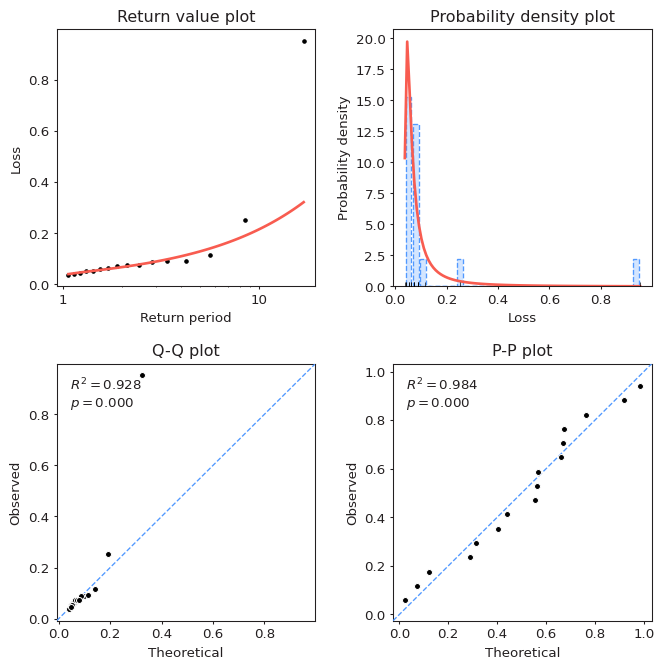

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:                          Loss      Size:                               3,913
Start:                       January 2003      End:                          August 2018
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                 16      Extraction method:                     BM
Type:                                high      Block size:             365 days 05:49:12
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pyextremes import EVA
import os


data_path = f'../data/asset_analysis/{asset_name}_analysis.csv'
df = pd.read_csv(data_path, parse_dates=['date'], index_col='date')
losses = df['Loss'].dropna()


model = EVA(losses)
model.get_extremes(method="BM", block_size="365.2425D")

# Fit the GEV distribution via Maximum Likelihood Estimation
model.fit_model()

# Plot the GEV diagnostics (Return Level plot, Q-Q, P-P, Density)
os.makedirs('../report/figures', exist_ok=True)
fig, axes = model.plot_diagnostic()
plt.savefig(f'../report/figures/{asset_name}_BMA.png', dpi=300)
plt.show()

print(model)

## after some discussion with Gemini

While statistically elegant, the Block Maxima method suffers from small-sample uncertainty. 
We 'only' have 15 years of JSE data (2003–2018), 15 annual maxima to fit the GEV. Estimating the shape parameter precisely from 15 data points is difficult. 
Additionally, my approach wastes data: if the second-worst loss in 2008 was worse than the worst loss in 2005, it is completely ignored, and we are still battling the assumption that these annual shocks are IID despite obvious volatility clustering during financial crises. Yet, it is still and improvment over the CLT

## My thoughts

Looking at the single black dot way up at the top right of the first plot, sitting near a log loss of 0.9 (massive market crash). The red predictive curve moves upward to try and capture it, but it falls significantly short. This tells us that the GEV model is likely underestimating the magnitude of the absolute worst "Black Swan" events.